# Parallel Workflow

This notebook demonstrates a parallel workflow.

We are evaluating an essay on different parameters.

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator
load_dotenv()
model=ChatOpenAI(model='gpt-4o-mini')

In [2]:
class evaluationSchema(BaseModel):
    feedback: str= Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10')    

In [3]:
structured_model= model.with_structured_output(evaluationSchema)

In [4]:
class upscstate(TypedDict):
    essay: str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str

    overall_feedback: str

    individual_scores: Annotated[list[int],operator.add]
    avg_score:float

In [5]:
def evaluate_language(state:upscstate):
    prompt= f"evaluate essay's language quality and provide feedback and score out of 10. Essay: {state['essay']}"
    output= structured_model.invoke(prompt)


    return {'language_feedback':output.feedback,
            'individual_scores':[output.score]}




In [6]:
def evaluate_analysis(state:upscstate):
    prompt= f"evaluate essay's depth of analysis and provide feedback and score out of 10. Essay: {state['essay']}"
    output= structured_model.invoke(prompt)


    return {'analysis_feedback':output.feedback,
            'individual_scores':[output.score]}


In [7]:
def evaluate_thought(state:upscstate):
    prompt= f"evaluate essay's clarity of thought and provide feedback and score out of 10. Essay: {state['essay']}"
    output= structured_model.invoke(prompt)


    return {'clarity_feedback':output.feedback,
            'individual_scores':[output.score]}


In [13]:
def final_evaluation(state:upscstate):
   #summary feedback

   prompt=f"""based on following feedbacks create a summarized feedback
   \n language feedback - {state['language_feedback']}
    \n analysis feedback - {state['analysis_feedback']}
    \n clarity  of thought feedback - {state['clarity_feedback']}
   """
   overall_feedback=model.invoke(prompt).content
   #average 


   avg_score=sum(state['individual_scores'])/len(state['individual_scores'])
   return {'overall_feedback':overall_feedback,
           'avg_score':avg_score}

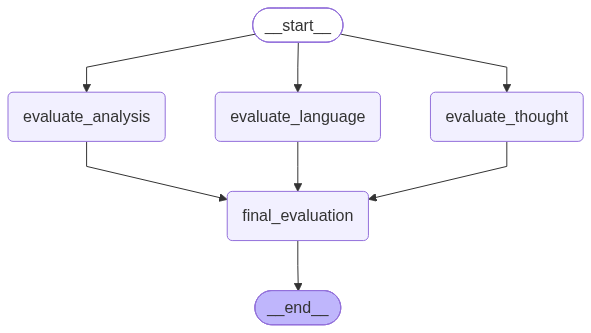

In [14]:
graph= StateGraph(upscstate)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)


#edges
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow=graph.compile()
workflow

In [15]:
essay=""" The Maritime Industry. The maritime industry is one of the most important sectors in the global economy. It is responsible for transporting around 80–90% of the world's international trade by volume, making it the backbone of global commerce. Ships carry a wide range of cargo, including raw materials, fuel, food products, vehicles, and consumer goods, connecting countries and supporting economic growth.
The industry consists of several sectors, such as commercial shipping, ports and logistics, offshore energy, shipbuilding, and maritime technology. Modern vessels use advanced navigation systems, satellite communication, and automation to improve safety and operational efficiency. In recent years, artificial intelligence, the Internet of Things (IoT), and data analytics have also become important in optimizing ship performance and reducing operational costs.
Despite its importance, the maritime industry faces several challenges. Environmental concerns, including greenhouse gas emissions and marine pollution, have led to stricter international regulations. The industry is increasingly adopting cleaner fuels, energy-efficient ship designs, and digital technologies to reduce its environmental impact. Additionally, cybersecurity has become a growing concern as ships and ports become more connected through digital systems.
Looking ahead, the maritime industry is expected to become more sustainable and technologically advanced. Innovations such as autonomous vessels, smart ports, and AI-powered decision-making systems have the potential to transform global shipping. As international trade continues to grow, the maritime industry will remain a vital part of the world's transportation and supply chain network.
"""
initial_state={
    "essay":essay
}

workflow.invoke(initial_state)

{'essay': " The Maritime Industry. The maritime industry is one of the most important sectors in the global economy. It is responsible for transporting around 80–90% of the world's international trade by volume, making it the backbone of global commerce. Ships carry a wide range of cargo, including raw materials, fuel, food products, vehicles, and consumer goods, connecting countries and supporting economic growth.\nThe industry consists of several sectors, such as commercial shipping, ports and logistics, offshore energy, shipbuilding, and maritime technology. Modern vessels use advanced navigation systems, satellite communication, and automation to improve safety and operational efficiency. In recent years, artificial intelligence, the Internet of Things (IoT), and data analytics have also become important in optimizing ship performance and reducing operational costs.\nDespite its importance, the maritime industry faces several challenges. Environmental concerns, including greenhouse